In [9]:
# 1. IMPORTATION DES LIBRAIRIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [10]:
# 1. CHARGEMENT DES DONNEES
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Outliers reconnus dans Ames Housing (selon le document de recherche fournit avec le cas)
train_df = train_df[train_df['GrLivArea'] < 4000].reset_index(drop=True)

y_train_log = np.log1p(train_df["SalePrice"].copy())

# Analyse rapide des valeurs manquantes sur train + test
all_data = pd.concat([train_df.drop('SalePrice', axis=1), test_df], axis=0, ignore_index=True)

# Sauvegarde des IDs pour la soumission finale Kaggle, puis suppression
test_ids = test_df['Id'].copy()
all_data = all_data.drop(['Id'], axis=1)


missing_counts = all_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(f'DONNÉES MANQUANTES ({len(missing_counts)} colonnes)')
for col, count in missing_counts.items():
    pct = 100 * count / len(all_data)
    print(f'   {col:20s} : {count:4d} ({pct:5.1f}%)')

DONNÉES MANQUANTES (34 colonnes)
   PoolQC               : 2907 ( 99.7%)
   MiscFeature          : 2810 ( 96.4%)
   Alley                : 2717 ( 93.2%)
   Fence                : 2345 ( 80.4%)
   MasVnrType           : 1765 ( 60.5%)
   FireplaceQu          : 1420 ( 48.7%)
   LotFrontage          :  486 ( 16.7%)
   GarageQual           :  159 (  5.5%)
   GarageYrBlt          :  159 (  5.5%)
   GarageCond           :  159 (  5.5%)
   GarageFinish         :  159 (  5.5%)
   GarageType           :  157 (  5.4%)
   BsmtExposure         :   82 (  2.8%)
   BsmtCond             :   82 (  2.8%)
   BsmtQual             :   81 (  2.8%)
   BsmtFinType2         :   80 (  2.7%)
   BsmtFinType1         :   79 (  2.7%)
   MasVnrArea           :   23 (  0.8%)
   MSZoning             :    4 (  0.1%)
   BsmtFullBath         :    2 (  0.1%)
   Functional           :    2 (  0.1%)
   BsmtHalfBath         :    2 (  0.1%)
   Utilities            :    2 (  0.1%)
   BsmtFinSF1           :    1 (  0.0%)
   Exte

In [11]:
# Suppression de lignes uniquement si le NA est considéré comme une erreur de saisie
error_missing_cols = [
    'MSZoning', 'BsmtFullBath', 'Functional', 'BsmtHalfBath', 'Utilities',
    'BsmtFinSF1', 'Exterior2nd', 'Exterior1st', 'Electrical', 'TotalBsmtSF',
    'BsmtUnfSF', 'BsmtFinSF2', 'KitchenQual', 'GarageArea', 'GarageCars', 'SaleType'
 ]

valid_error_cols = [c for c in error_missing_cols if c in train_df.columns]
dropped_error_cols = [c for c in error_missing_cols if c not in train_df.columns]

print(f'Colonnes a verifier pour NA erreurs : {valid_error_cols}')
if dropped_error_cols:
    print(f'Colonnes ignorees (absentes de train.csv): {dropped_error_cols}')

n_before_drop = len(train_df)
train_df = train_df.dropna(subset=valid_error_cols).reset_index(drop=True)
n_removed = n_before_drop - len(train_df)
print(f'Lignes supprimees sur train_df (NA erreurs): {n_removed}')

ntrain = len(train_df)
y_train_log = np.log1p(train_df['SalePrice'].copy())
test_ids = test_df['Id'].copy()
all_data = pd.concat([train_df.drop(columns=['SalePrice']), test_df], axis=0).reset_index(drop=True)
all_data = all_data.drop(columns=['Id'])

print(f'Shape all_data : {all_data.shape}')

Colonnes a verifier pour NA erreurs : ['MSZoning', 'BsmtFullBath', 'Functional', 'BsmtHalfBath', 'Utilities', 'BsmtFinSF1', 'Exterior2nd', 'Exterior1st', 'Electrical', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'KitchenQual', 'GarageArea', 'GarageCars', 'SaleType']
Lignes supprimees sur train_df (NA erreurs): 1
Shape all_data : (2914, 79)


In [12]:
# 2. NETTOYAGE GLOBAL SUR ALL_DATA

def apply_base_preprocessing(data):
    """Applique le nettoyage de base sur l'ensemble complet (Train + Test)"""
    df = data.copy()

    # 1. NA signifiant "Absence de l'équipement" -> Catégorie 'None'
    cols_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
                 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
    for col in cols_none:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    # 2. NA signifiant 0 pour les variables numériques
    cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
    for col in cols_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 3. Imputation par la médiane globale pour la façade (LotFrontage)
    if 'LotFrontage' in df.columns:
        df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    # Imputation par le mode pour les vrais manquants
    cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional', 'Utilities']
    for col in cols_mode:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # 6. Feature Engineering
    # Choix volontaire : garder une variable synthétique de surface plutôt que plusieurs doublons exacts
    if {'TotalBsmtSF', '1stFlrSF', '2ndFlrSF'}.issubset(df.columns):
        df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)
    if {'TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'}.issubset(df.columns):
        basement_total = df['TotalBsmtSF'].replace(0, np.nan)
        df['BasementFinishedShare'] = ((df['BsmtFinSF1'] + df['BsmtFinSF2']) / basement_total).fillna(0)
        df['BasementUnfinishedShare'] = (df['BsmtUnfSF'] / basement_total).fillna(0)

    if {'TotalSF', '2ndFlrSF'}.issubset(df.columns):
        total_sf = df['TotalSF'].replace(0, np.nan)
        df['SecondFloorShare'] = (df['2ndFlrSF'] / total_sf).fillna(0)

    if {'YrSold', 'YearBuilt'}.issubset(df.columns):
        df['AgeAtSale'] = df['YrSold'] - df['YearBuilt']
    if {'YrSold', 'YearRemodAdd'}.issubset(df.columns):
        df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    
    cols_to_drop = ['GarageArea', 'TotRmsAbvGrd', 'GarageYrBlt', 'YearBuilt', 'YearRemodAdd', 'YrSold',
                    'TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# Application du nettoyage
all_data_clean = apply_base_preprocessing(all_data)

# 3. SÉPARATION TRAIN / TEST

# On utilise ntrain pour retrouver nos données d'entraînement exactes
X_train_clean = all_data_clean.iloc[:ntrain].copy()
X_test_clean = all_data_clean.iloc[ntrain:].copy()

print(f"Shape X_train_clean : {X_train_clean.shape}")
print(f"Shape X_test_clean  : {X_test_clean.shape}")

Shape X_train_clean : (1455, 73)
Shape X_test_clean  : (1459, 73)


Corrélations fortes (|r| > 0.85) sur X_train_clean
  BasementFinishedShare <-> BasementUnfinishedShare : -0.907
  GrLivArea            <-> TotalSF              : 0.861


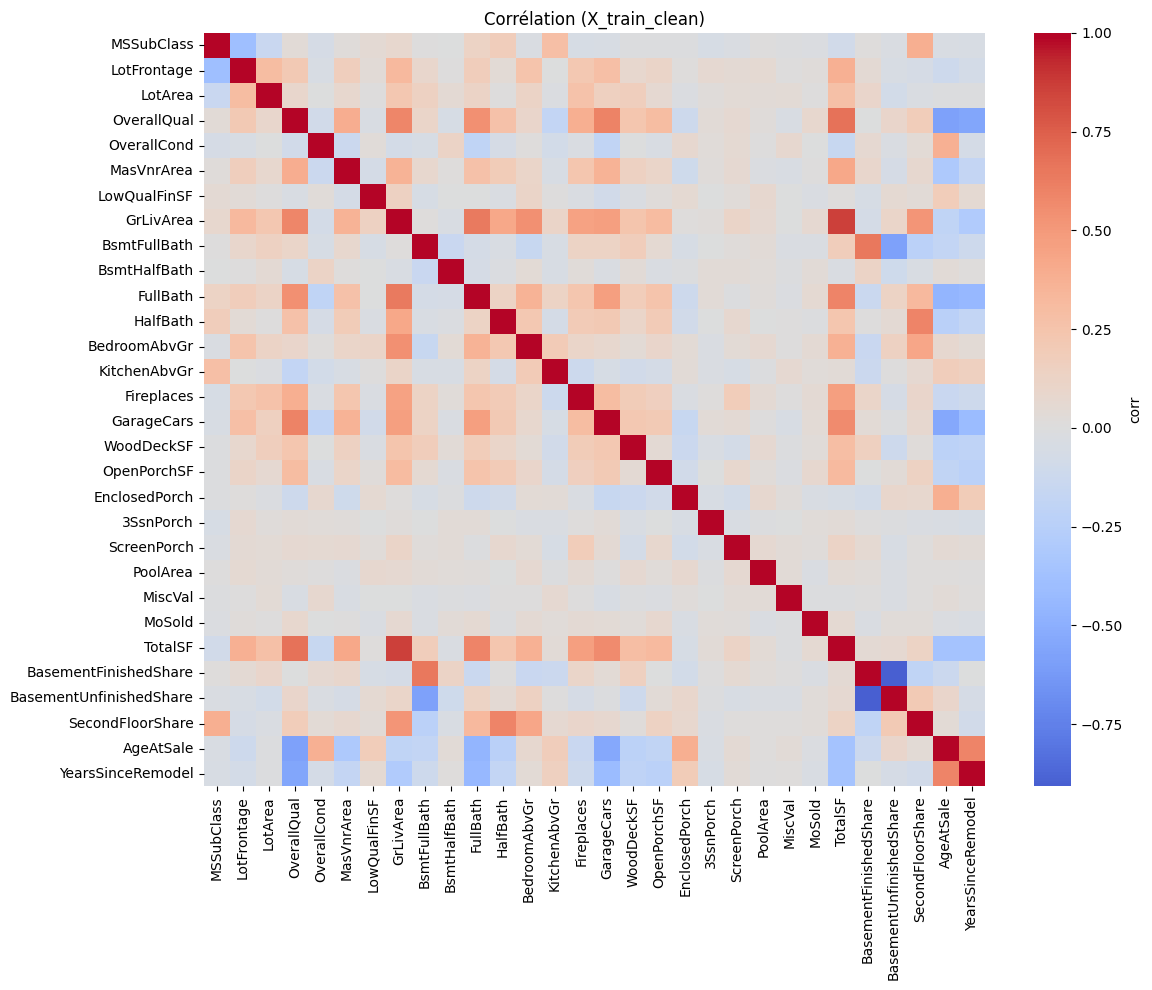

                    feature         vif
7                 GrLivArea  231.398516
24                  TotalSF  224.250422
3               OverallQual   56.039351
4               OverallCond   36.151945
13             KitchenAbvGr   29.865785
10                 FullBath   25.817353
12             BedroomAbvGr   25.031314
26  BasementUnfinishedShare   24.950568
25    BasementFinishedShare   20.614509
1               LotFrontage   17.918042
15               GarageCars   13.002037
28                AgeAtSale   10.404361
27         SecondFloorShare    9.076568
23                   MoSold    6.572111
0                MSSubClass    4.968717
29        YearsSinceRemodel    4.461851
8              BsmtFullBath    3.645095
11                 HalfBath    3.476561
14               Fireplaces    2.869458
2                   LotArea    2.619354


In [13]:
# 3. ANALYSE DE LA MULTICOLINEARITE SUR LE TRAIN SEULEMENT
num_cols = X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr = X_train_clean[num_cols].corr()

print('Corrélations fortes (|r| > 0.85) sur X_train_clean')
high_pairs = []
thr = 0.85
for i, a in enumerate(corr.columns):
    for b in corr.columns[i+1:]:
        if abs(corr.loc[a, b]) > thr:
            high_pairs.append((a, b, corr.loc[a, b]))

high_pairs_sorted = sorted(high_pairs, key=lambda x: -abs(x[2]))
for a, b, r in high_pairs_sorted:
    print(f"  {a:20s} <-> {b:20s} : {r:.3f}")

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'label': 'corr'})
plt.title('Corrélation (X_train_clean)')
plt.tight_layout()
plt.show()

# VIF : on retire les lignes manquantes pour pouvoir calculer l'indicateur
X_vif = X_train_clean[num_cols].dropna().copy()
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('vif', ascending=False)

print(vif_df.head(20))

In [14]:
# 4. ENCODAGE AVANCÉ

class AdvancedCategoricalEngineer(BaseEstimator, TransformerMixin):
    """Transformateur Scikit-Learn pour encodage ordinal et Target Encoding (sklearn)."""
    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.qual_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
        self.ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                             'HeatingQC', 'KitchenQual', 'FireplaceQu',
                             'GarageQual', 'GarageCond', 'PoolQC']
        self.te = None
        self.nominal_cols = None

    def fit(self, X, y):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        self.nominal_cols = X_copy.select_dtypes(include=['object', 'string']).columns.tolist()

        for col in self.nominal_cols:
            X_copy[col] = X_copy[col].astype(str).fillna('Missing')

        self.te = TargetEncoder(cols=self.nominal_cols, smoothing=self.smoothing)
        self.te.fit(X_copy[self.nominal_cols], y)
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        if self.nominal_cols:
            for col in self.nominal_cols:
                if col in X_copy.columns:
                    X_copy[col] = X_copy[col].astype(str).fillna('Missing')
            X_copy[self.nominal_cols] = self.te.transform(X_copy[self.nominal_cols])

        return X_copy


# 5. VALIDATION CROISÉE - RÉGRESSION LASSO

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

print("\nDébut Validation Croisée Lasso (5-Fold)...")
# Pipeline M1 version Lasso
pipeline_m1_lasso = Pipeline([
    ('encoder', AdvancedCategoricalEngineer(smoothing=10.0)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.0005, max_iter=20000))
])

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):

    # Séparation locale pour ce pli
    X_tr, y_tr = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
    X_val, y_val = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]

    # Entraînement et Prédiction
    pipeline_m1_lasso.fit(X_tr, y_tr)
    preds = pipeline_m1_lasso.predict(X_val)

    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(fold_rmse)
    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.5f}")

print(f"\nRMSE Moyen (CV) : {np.mean(rmse_scores):.5f} (+/- {np.std(rmse_scores):.5f})")


Début Validation Croisée Lasso (5-Fold)...
Fold 1 | RMSE: 0.12043
Fold 2 | RMSE: 0.12264
Fold 3 | RMSE: 0.12339
Fold 4 | RMSE: 0.12613
Fold 5 | RMSE: 0.09691

RMSE Moyen (CV) : 0.11790 (+/- 0.01065)


In [15]:
# Contrôle des valeurs manquantes sur le test après préprocessing
print(X_test_clean.isna().sum().sort_values(ascending=False).head(20))

MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
Alley           0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
RoofStyle       0
RoofMatl        0
dtype: int64


# PHASE 3 : MODÉLISATION (BASELINE → OPTIMISATION)

In [16]:
# 9. PIPELINE OPTIMISÉ (QuantileTransformer + Date Transformer + Lasso avec alphas fins)
print("\n" + "="*70)
print("PIPELINE OPTIMISÉ (QuantileTransformer + Fine Alphas)")
print("="*70)

numeric_transformer_optimized = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42))
])

date_transformer_optimized = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42))
])

categorical_transformer_optimized = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10.0))
])

# Définition des features numériques et catégoriques (assure que les variables existent)
numeric_features = X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_clean.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
print(f"Features numériques: {len(numeric_features)}, catégoriques: {len(categorical_features)}")

# Valider que les colonnes listées existent bien (certaines peuvent avoir été supprimées précédemment)
numeric_features_valid = [c for c in numeric_features if c in X_train_clean.columns]
categorical_features_valid = [c for c in categorical_features if c in X_train_clean.columns]

missing_num = sorted(set(numeric_features) - set(numeric_features_valid))
missing_cat = sorted(set(categorical_features) - set(categorical_features_valid))
if missing_num or missing_cat:
    print("\nAttention: certaines colonnes listées comme features sont absentes après preprocessing:")
    if missing_num:
        print(f"   - Numériques manquantes ({len(missing_num)}): {missing_num}")
    if missing_cat:
        print(f"   - Catégoriques manquantes ({len(missing_cat)}): {missing_cat}")

preprocessor_optimized = ColumnTransformer(transformers=[
    ('num', numeric_transformer_optimized, numeric_features_valid),
    ('cat', categorical_transformer_optimized, categorical_features_valid)
])

lasso_optimized = LassoCV(alphas=np.logspace(-6, 1, 1000), cv=5, random_state=42, max_iter=10000, tol=1e-4)

pipeline_optimized = Pipeline(steps=[
    ('preprocessor', preprocessor_optimized),
    ('model', lasso_optimized)
])

print("\nPipeline optimisé créé:")
print("   • Numérique: Imputation (médiane) + QuantileTransformer")
print("   • Catégorique: Imputation (mode) + TargetEncoder(cv=5)")
print("   • Modèle: LassoCV(alphas=-6 à +1, 1000 points, cv=5)")

print("\n   Entraînement...")
# S'assurer que la cible alignée correspond bien au X utilisé (évite mismatch si train a été modifié)
y_train_for_fit = y_train_log.iloc[: X_train_clean.shape[0] ].reset_index(drop=True)
pipeline_optimized.fit(X_train_clean, y_train_for_fit)

y_pred_opt = pipeline_optimized.predict(X_train_clean)
rmse_opt = np.sqrt(mean_squared_error(y_train_for_fit, y_pred_opt))
mae_opt = mean_absolute_error(y_train_for_fit, y_pred_opt)
r2_opt = r2_score(y_train_for_fit, y_pred_opt)
alpha_opt = pipeline_optimized.named_steps['model'].alpha_

print(f"\nMÉTRIQUES OPTIMISÉES:")
print(f"   RMSE: {rmse_opt:.4f}")
print(f"   MAE: {mae_opt:.4f}")
print(f"   R²: {r2_opt:.4f}")
print(f"   Alpha: {alpha_opt:.6f}")


PIPELINE OPTIMISÉ (QuantileTransformer + Fine Alphas)
Features numériques: 30, catégoriques: 43

Pipeline optimisé créé:
   • Numérique: Imputation (médiane) + QuantileTransformer
   • Catégorique: Imputation (mode) + TargetEncoder(cv=5)
   • Modèle: LassoCV(alphas=-6 à +1, 1000 points, cv=5)

   Entraînement...

MÉTRIQUES OPTIMISÉES:
   RMSE: 0.1111
   MAE: 0.0799
   R²: 0.9213
   Alpha: 0.000131


# PHASE 5 : PRÉDICTIONS & SOUMISSION

In [17]:
# 15. PRÉDICTIONS FINALES
print("\n" + "="*70)
print("PRÉDICTIONS FINALES")
print("="*70)

# Optimisé
y_pred_log_opt = pipeline_optimized.predict(X_test_clean)
y_pred_dollars_opt = np.expm1(y_pred_log_opt)

print(f"\nModèle Optimisé:")
print(f"   Min: ${y_pred_dollars_opt.min():,.0f}")
print(f"   Max: ${y_pred_dollars_opt.max():,.0f}")
print(f"   Médiane: ${np.median(y_pred_dollars_opt):,.0f}")
print(f"   Moyenne: ${y_pred_dollars_opt.mean():,.0f}")



PRÉDICTIONS FINALES

Modèle Optimisé:
   Min: $53,900
   Max: $824,214
   Médiane: $158,662
   Moyenne: $178,301


In [18]:
# 16. GÉNÉRATION FICHIERS CSV & RÉSUMÉ FINAL
print("\n" + "="*70)
print("GÉNÉRATION FICHIERS SUBMISSIONS")
print("="*70)

submission_opt = pd.DataFrame({
    'Id': test_ids.values,
    'SalePrice': y_pred_dollars_opt
})
submission_opt.to_csv('M1_Lasso_V6_v2.csv', index=False)
print(f"\nM1_Lasso_V6_v2.csv généré ({len(submission_opt)} prédictions)")

# RÉSUMÉ FINAL (sans export Optuna)
print(f"\n{'='*70}")
print("RÉSUMÉ FINAL - SUBMISSION")
print(f"{'='*70}")

summary_text = f"""

MEILLEUR MODÈLE (parmi évalués):
    • RMSE: {rmse_opt:.4f}
    • MAE: {mae_opt:.4f}
    • R²: {r2_opt:.4f}
    • Scaler recommandé: QuantileTransformer

FICHIER GÉNÉRÉ:
    • M1_Lasso_V6_v2.csv

"""

print(summary_text)


GÉNÉRATION FICHIERS SUBMISSIONS

M1_Lasso_V6_v2.csv généré (1459 prédictions)

RÉSUMÉ FINAL - SUBMISSION


MEILLEUR MODÈLE (parmi évalués):
    • RMSE: 0.1111
    • MAE: 0.0799
    • R²: 0.9213
    • Scaler recommandé: QuantileTransformer

FICHIER GÉNÉRÉ:
    • M1_Lasso_V6_v2.csv


